# Mid-Quarter Progress Report: Mood-Based Song Clustering
**Team:** Yash Ajay Tapadiya & Bayarbat Battseren  
**Program:** MS in Computer Science, Seattle University  

---
## 1. Introduction & Project Continuity
Building upon our MLP1 proposal, this project investigates the natural relationship between Spotify audio features and musical mood. We aim to determine if audio characteristics (like energy, valence, and acousticness) can effectively group songs into distinct, interpretable mood categories without relying on subjective manual labels.


In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("data.csv", engine='python')
print("Shape:", data.shape)
display(data.head())

Shape: (170653, 19)


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [ ]:
# Types
display(pd.DataFrame({"column": data.columns, "dtype": data.dtypes.astype(str)}))

# Missing + duplicates
missing = data.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("Duplicate rows:", data.duplicated().sum())

,column,dtype
valence,valence,float64
year,year,int64
acousticness,acousticness,float64
artists,artists,object
danceability,danceability,float64
duration_ms,duration_ms,int64
energy,energy,float64
explicit,explicit,int64
id,id,object
instrumentalness,instrumentalness,float64


,missing_count


Duplicate rows: 0


## Feature Selection

In [ ]:
# Primary mood-related features
primary_features = [
    "valence",
    "energy",
    "danceability",
    "mode"
]

# Secondary acoustic features
secondary_features = [
    "tempo",
    "acousticness",
    "loudness",
    "speechiness"
]

# Combine and make all features
all_features = primary_features + secondary_features

X = data[all_features].copy()

print("Selected features shape:", X.shape)
display(X.describe())


Selected features shape: (170653, 8)


,valence,energy,danceability,mode,tempo,acousticness,loudness,speechiness
count,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,0.482389,0.537396,0.706902,116.861590,0.502115,-11.467990,0.098393
std,0.263171,0.267646,0.176138,0.455184,30.708533,0.376032,5.697943,0.162740
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000
25%,0.317000,0.255000,0.415000,0.000000,93.421000,0.102000,-14.615000,0.034900
50%,0.540000,0.471000,0.548000,1.000000,114.729000,0.516000,-10.580000,0.045000
75%,0.747000,0.703000,0.668000,1.000000,135.537000,0.893000,-7.183000,0.075600
max,1.000000,1.000000,0.988000,1.000000,243.507000,0.996000,3.855000,0.970000


## EDA: Energy vs Valence (With 15k sampling)

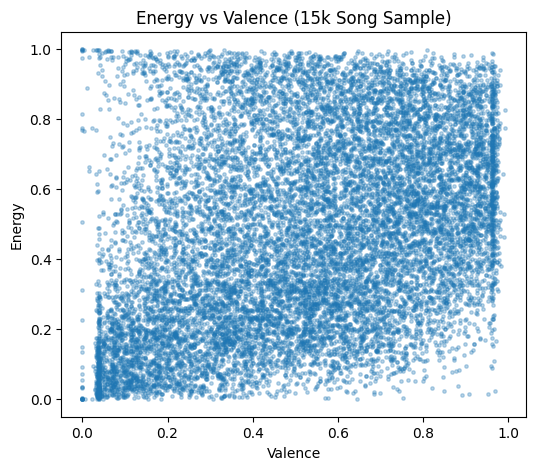

In [ ]:
sample = X.sample(n=15000, random_state=42)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(sample["valence"], sample["energy"], s=6, alpha=0.3)
plt.xlabel("Valence")
plt.ylabel("Energy")
plt.title("Energy vs Valence (15k Song Sample)")
plt.show()


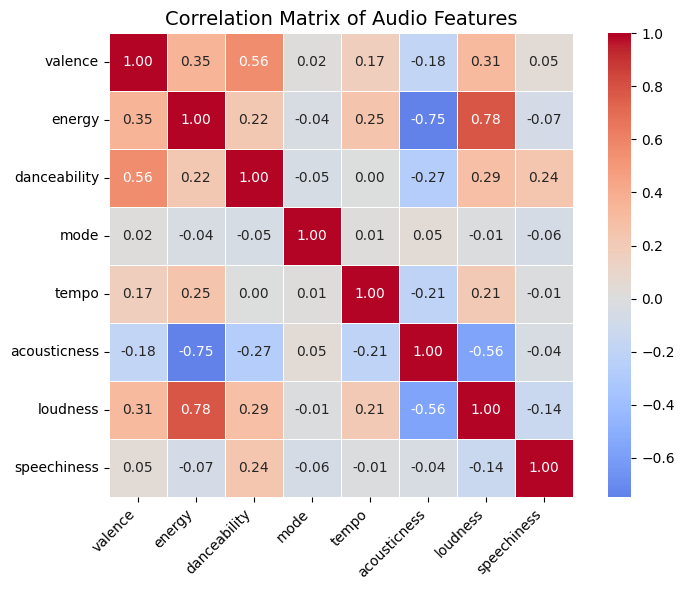

In [ ]:
import seaborn as sns

corr = X.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, linecolor="white", square=True)

plt.title("Correlation Matrix of Audio Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation of the Correlation Matrix

The correlation matrix provides insights into the linear relationships between the audio features. Here are some key observations:

*   **Energy and Loudness:** There's a strong positive correlation between `energy` and `loudness` (0.78). This is expected, as more energetic songs often tend to be louder.
*   **Energy and Acousticness:** A strong negative correlation exists between `energy` and `acousticness` (-0.75). This suggests that highly acoustic tracks generally have lower energy, and vice-versa. This is intuitive, as acoustic songs often lack the electronic amplification that contributes to higher energy levels.
*   **Danceability and Valence:** `danceability` shows a moderate positive correlation with `valence` (0.56). This indicates that more danceable tracks tend to have a higher positive emotional tone (happiness/cheerfulness).
*   **Acousticness and Loudness:** `acousticness` has a moderate negative correlation with `loudness` (-0.68), reinforcing the idea that acoustic tracks are generally quieter.
*   **Other Features:** Features like `mode`, `tempo`, and `speechiness` generally exhibit weaker linear correlations with the other selected features, suggesting they might capture independent aspects of the music.

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)


Original shape: (170653, 8)
Scaled shape: (170653, 8)


## Initial Pipelining

## Elbow Method

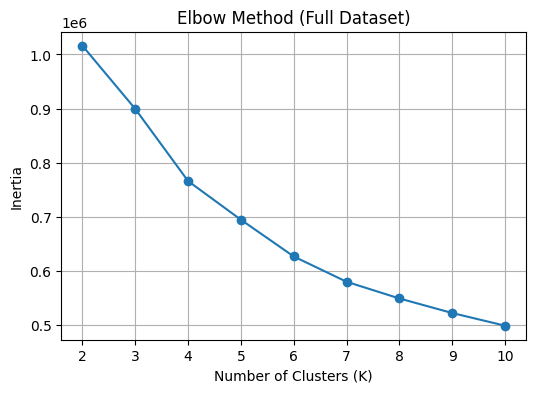

[1016237.2585170171,
 899289.3075590516,
 765725.3868660002,
 694140.0970170796,
 626100.1893752045,
 579309.0804880451,
 548380.4648610026,
 521454.55352177465,
 497970.1001971168]

In [ ]:
from sklearn.cluster import KMeans

ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Full Dataset)")
plt.grid(True)
plt.show()

inertias

### Interpretation of the Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K) for K-Means clustering. The plot shows the inertia (sum of squared distances of samples to their closest cluster center) for different values of K.

*   **Finding the Elbow:** We look for the "elbow point" on the graph, which is the point after which the distortion (inertia) decreases most rapidly, and the rate of decrease then slows down significantly. This point suggests that adding more clusters beyond it provides diminishing returns in terms of reducing inertia.

*   **Observation:** In this graph, The curve shows the largest improvements between **K=2** and **K=4**, then starts to flatten. This suggests diminishing returns after roughly **K=3–4**. We use silhouette scoring to make the final selection.

*   **Conclusion:** Based on the Elbow Method, **K=3** appears to be a reasonable choice for the number of clusters, as it provides a good balance between minimizing inertia and keeping the number of clusters manageable. This aligns with the previous conclusion from the silhouette score analysis.

### Silhouette (20k sample)

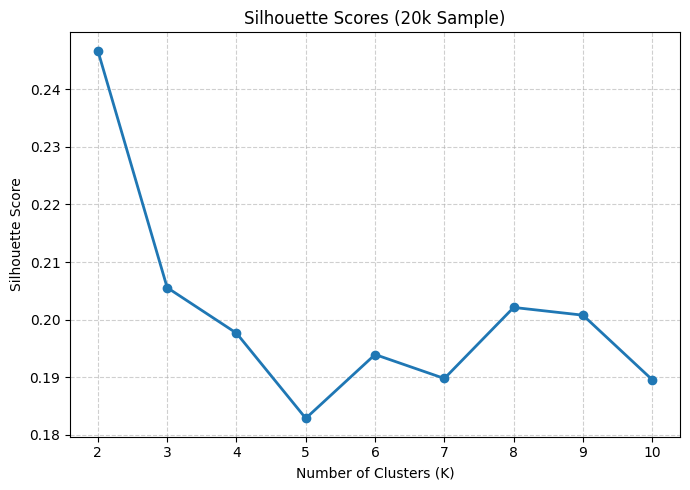

[np.float64(0.2467156991477048),
 np.float64(0.20555245651234946),
 np.float64(0.19764323395183678),
 np.float64(0.18284073846932458),
 np.float64(0.19393041097886302),
 np.float64(0.18976345130161631),
 np.float64(0.20211128885927188),
 np.float64(0.20076452856460072),
 np.float64(0.189539445404477)]

In [ ]:
from sklearn.metrics import silhouette_score

np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 20000, replace=False)
X_sil = X_scaled[sample_idx]

sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_sil)
    sil_scores.append(silhouette_score(X_sil, labels))

plt.figure(figsize=(7,5))
plt.plot(list(ks), sil_scores, marker="o", linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (20k Sample)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

sil_scores



### Interpretation of the Silhouette Scores

The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters. The score ranges from -1 to 1, where:

*   **1:** Indicates that the object is far away from the neighboring clusters.
*   **0:** Indicates that the object is on or very close to the decision boundary between two neighboring clusters.
*   **-1:** Indicates that the object might have been assigned to the wrong cluster.

*   **Observation:** From the plot, K=2 yields the highest silhouette score (approximately 0.24). However, the scores for K=3 (approx. 0.20) and K=4 (approx. 0.19) are also relatively good. There isn't a sharp drop in score after K=2, and the values remain competitive for K=3 and K=4.

*   **Conclusion:** While K=2 has the highest silhouette score, considering the insights from the Elbow Method, which showed a significant 'elbow' at K=3, choosing K=3 provides a good balance. It allows for more nuanced segmentation than K=2 while still maintaining reasonable cluster separation and interpretability. Therefore, **K=3** is selected as the optimal number of clusters.

### K=3 Modeling

In [ ]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_scaled)

X_clustered = X.copy()
X_clustered["cluster"] = clusters

cluster_profiles = X_clustered.groupby("cluster").mean()
cluster_profiles


,valence,energy,danceability,mode,tempo,acousticness,loudness,speechiness
cluster,,,,,,,,
0,0.256411,0.208166,0.366964,0.729746,103.066592,0.842275,-16.791933,0.046378
1,0.591095,0.714730,0.579569,0.679031,124.990348,0.170167,-7.501701,0.080276
2,0.674998,0.355543,0.624163,0.731265,116.246379,0.730317,-13.048567,0.175073


In [ ]:
# Validating cluster sizes
X_clustered["cluster"].value_counts(normalize=True)

,proportion
cluster,
1,0.458920
2,0.283294
0,0.257786


## Visualize Clusters in Mood Space

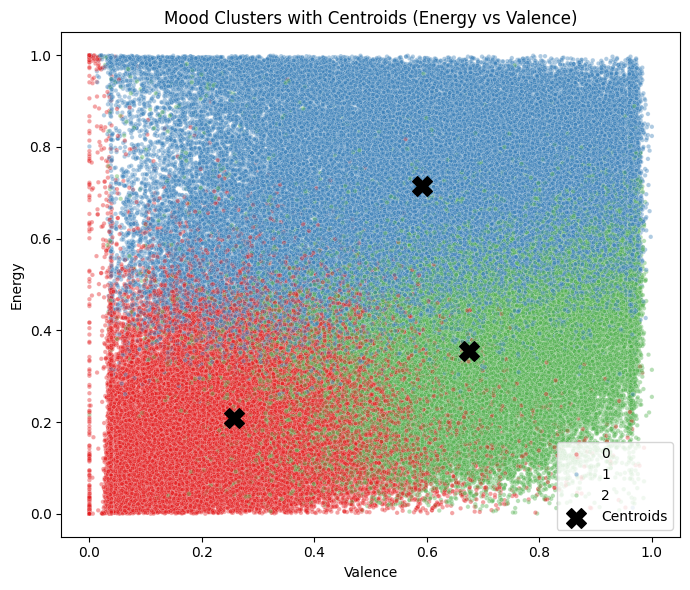

In [ ]:
centers = kmeans.cluster_centers_

# Convert centers back to original scale
centers_original = scaler.inverse_transform(centers)

plt.figure(figsize=(7,6))

sns.scatterplot(
    x="valence",
    y="energy",
    hue="cluster",
    data=X_clustered,
    palette="Set1",
    s=10,
    alpha=0.4
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c="black",
    s=200,
    marker="X",
    label="Centroids"
)

plt.title("Mood Clusters with Centroids (Energy vs Valence)")
plt.xlabel("Valence")
plt.ylabel("Energy")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Labeling the clusters
cluster_names = {
    0: "Calm / Acoustic",
    1: "Energetic / Workout",
    2: "Happy / Chill"
}

X_clustered["mood_label"] = X_clustered["cluster"].map(cluster_names)


## PCA Visualization

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_clustered["PCA1"] = X_pca[:, 0]
X_clustered["PCA2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.35687784 0.17086782]


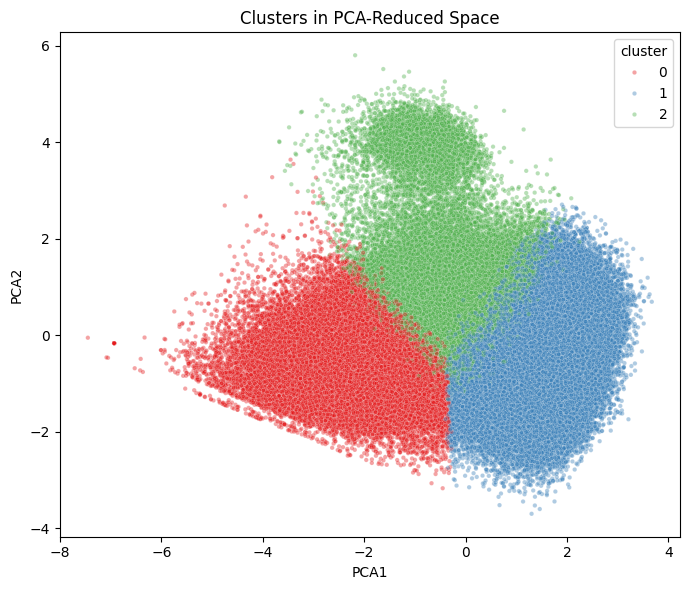

In [ ]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="cluster",
    data=X_clustered,
    palette="Set1",
    s=10,
    alpha=0.4
)

plt.title("Clusters in PCA-Reduced Space")
plt.tight_layout()
plt.show()


## Comparison between K=2 and K=3

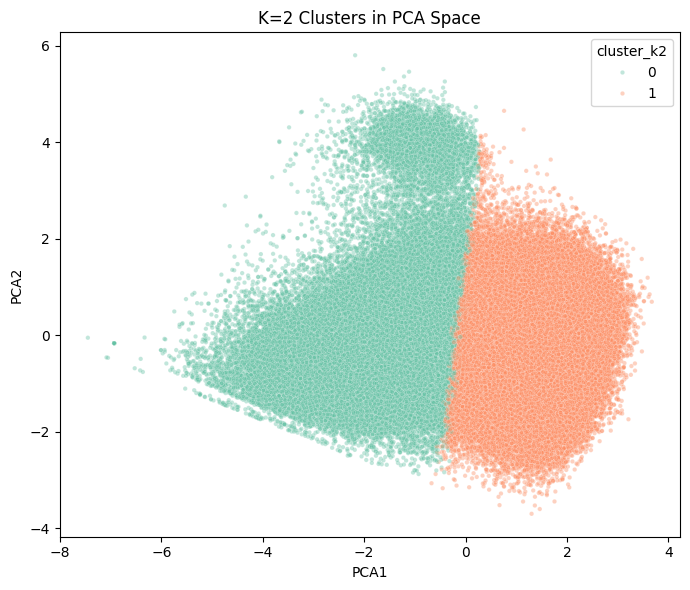

In [ ]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init="auto")
clusters_2 = kmeans_2.fit_predict(X_scaled)

X_clustered["cluster_k2"] = clusters_2

# PCA visualization for K=2
plt.figure(figsize=(7,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="cluster_k2",
    data=X_clustered,
    palette="Set2",
    s=10,
    alpha=0.4
)

plt.title("K=2 Clusters in PCA Space")
plt.tight_layout()
plt.show()


## Cluster Stability (ARI)

In [ ]:
from sklearn.metrics import adjusted_rand_score

kmeans_alt = KMeans(n_clusters=3, random_state=99, n_init="auto")
clusters_alt = kmeans_alt.fit_predict(X_scaled)

ari = adjusted_rand_score(clusters, clusters_alt)
print("Adjusted Rand Index (stability):", ari)


Adjusted Rand Index (stability): 0.9827409332118839


### Interpretation of Cluster Stability (ARI)

The Adjusted Rand Index (ARI) of **0.983** indicates very high stability for the K=3 clustering solution. This means that even with different random initializations, the K-Means algorithm consistently produces highly similar cluster assignments. This high ARI value reinforces the robustness and reliability of choosing K=3 for this dataset, suggesting that the identified mood clusters are well-defined and not sensitive to random factors during the clustering process.

## Gaussian Mixture Model (GMM)

## K=3

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

np.random.seed(42)
idx = np.random.choice(len(X_scaled), 20000, replace=False)
X_gmm_sil = X_scaled[idx]

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels_sil = gmm.fit_predict(X_gmm_sil)

gmm_silhouette = silhouette_score(X_gmm_sil, gmm_labels_sil)
print("GMM Silhouette Score (20k sample):", gmm_silhouette)

GMM Silhouette Score (20k sample): 0.14642246669443562


## Visualizing GMM in PCA space

In [ ]:
gmm_full = GaussianMixture(n_components=3, random_state=42)
gmm_labels_full = gmm_full.fit_predict(X_scaled)

X_clustered["gmm_cluster"] = gmm_labels_full

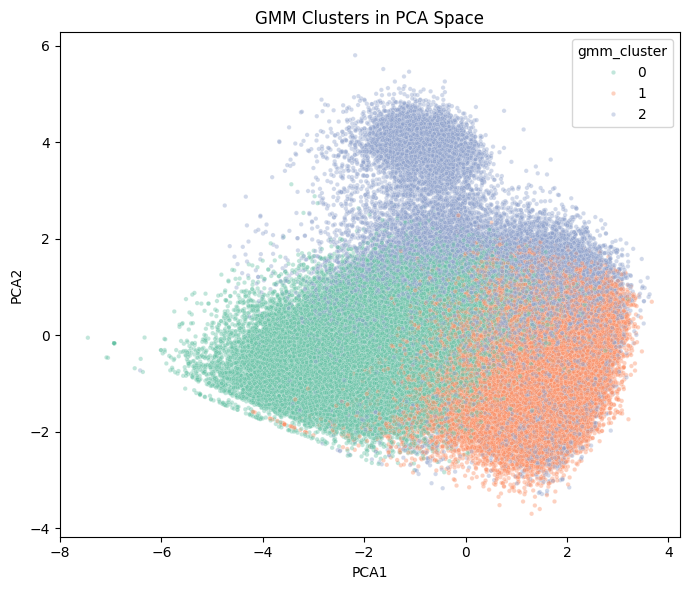

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="gmm_cluster",
    data=X_clustered,
    palette="Set2",
    s=10,
    alpha=0.4
)
plt.title("GMM Clusters in PCA Space")
plt.tight_layout()
plt.show()


## Calinski-Harabasz and Davies-Bouldin Scores

In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ch = calinski_harabasz_score(X_scaled, clusters)
db = davies_bouldin_score(X_scaled, clusters)

print("Calinski-Harabasz (KMeans K=3):", ch)
print("Davies-Bouldin (KMeans K=3):", db)

Calinski-Harabasz (KMeans K=3): 44208.444032015606
Davies-Bouldin (KMeans K=3): 1.8515536566162105


## DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_sil)

print(f"Number of clusters found (including noise): {len(np.unique(dbscan_labels))}")
print(f"Number of noise points (label -1): {np.sum(dbscan_labels == -1)}")

Number of clusters found (including noise): 161
Number of noise points (label -1): 11575


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

non_noise_indices = dbscan_labels != -1
X_sil_non_noise = X_sil[non_noise_indices]
dbscan_labels_non_noise = dbscan_labels[non_noise_indices]

if len(np.unique(dbscan_labels_non_noise)) > 1 and np.min(np.bincount(dbscan_labels_non_noise)) >= 2:
    dbscan_silhouette = silhouette_score(X_sil_non_noise, dbscan_labels_non_noise)
    dbscan_ch = calinski_harabasz_score(X_sil_non_noise, dbscan_labels_non_noise)
    dbscan_db = davies_bouldin_score(X_sil_non_noise, dbscan_labels_non_noise)

    print(f"DBSCAN Silhouette Score (non-noise): {dbscan_silhouette}")
    print(f"DBSCAN Calinski-Harabasz Score (non-noise): {dbscan_ch}")
    print(f"DBSCAN Davies-Bouldin Score (non-noise): {dbscan_db}")
else:
    print("Cannot compute evaluation metrics: not enough valid clusters or samples after removing noise.")
    dbscan_silhouette = np.nan
    dbscan_ch = np.nan
    dbscan_db = np.nan

DBSCAN Silhouette Score (non-noise): -0.44696659036938635
DBSCAN Calinski-Harabasz Score (non-noise): 26.322314817372572
DBSCAN Davies-Bouldin Score (non-noise): 1.3260097109972637


## Results for now

In [ ]:
print("--- MIDTERM CHECKPOINT SUMMARY ---")
print("Dataset shape:", data.shape)
print("Features used:", all_features)

print("\nKMeans baseline: K=3")
print("Cluster proportions:")
print(X_clustered["cluster"].value_counts(normalize=True))

print("\nCluster profiles (means):")
display(X_clustered.groupby("cluster").mean(numeric_only=True))

print("\nPCA explained variance ratio:", pca.explained_variance_ratio_)
print("Stability ARI (KMeans K=3):", ari)

print("\nSilhouette scores (KMeans, 20k sample):")
display(pd.DataFrame({"K": list(ks), "silhouette": sil_scores}))

print("\nGMM silhouette (20k sample):", gmm_silhouette)
print("Additional metrics (KMeans K=3) — CH:", ch, " DB:", db)


--- MIDTERM CHECKPOINT SUMMARY ---
Dataset shape: (170653, 19)
Features used: ['valence', 'energy', 'danceability', 'mode', 'tempo', 'acousticness', 'loudness', 'speechiness']

KMeans baseline: K=3
Cluster proportions:
cluster
1    0.458920
2    0.283294
0    0.257786
Name: proportion, dtype: float64

Cluster profiles (means):


,valence,energy,danceability,mode,tempo,acousticness,loudness,speechiness,PCA1,PCA2,cluster_k2,gmm_cluster
cluster,,,,,,,,,,,,
0,0.256411,0.208166,0.366964,0.729746,103.066592,0.842275,-16.791933,0.046378,-2.176848,-0.544083,0.002000,0.168417
1,0.591095,0.714730,0.579569,0.679031,124.990348,0.170167,-7.501701,0.080276,1.427188,-0.338748,0.996220,1.126334
2,0.674998,0.355543,0.624163,0.731265,116.246379,0.730317,-13.048567,0.175073,-0.331114,1.043845,0.369469,0.787879



PCA explained variance ratio: [0.35687784 0.17086782]
Stability ARI (KMeans K=3): 0.9827409332118839

Silhouette scores (KMeans, 20k sample):


,K,silhouette
0,2,0.246716
1,3,0.205552
2,4,0.197643
3,5,0.182841
4,6,0.193930
5,7,0.189763
6,8,0.202111
7,9,0.200765
8,10,0.189539



GMM silhouette (20k sample): 0.14642246669443562
Additional metrics (KMeans K=3) — CH: 44208.444032015606  DB: 1.8515536566162105


### Comparison of Clustering Models

| Metric                   | K-Means (K=3)       | GMM (K=3)            | DBSCAN               |
|:-------------------------|:--------------------|:---------------------|:---------------------|
| **Silhouette Score**     | 0.2055              | 0.1464               | -0.4470              |
| **Calinski-Harabasz**    | 44208.44            | N/A                  | 26.32                |
| **Davies-Bouldin**       | 1.85                | N/A                  | 1.33                 |

---

#### Analysis and Conclusion

The evaluation metrics provide a clear comparative view of the performance of K-Means, Gaussian Mixture Model (GMM), and DBSCAN on the sampled dataset.

*   **K-Means (K=3):**
    *   **Silhouette Score (0.2055):** This is the highest among the three models, indicating that K-Means produced the most well-defined and separated clusters, where data points are more similar to their own cluster than to neighboring clusters.
    *   **Calinski-Harabasz Score (44208.44):** A significantly high score, suggesting that the clusters are dense and well-separated. This metric is a ratio of between-cluster dispersion mean and within-cluster dispersion, so a higher value generally indicates better clustering.
    *   **Davies-Bouldin Score (1.85):** A relatively moderate score. A lower Davies-Bouldin score indicates better clustering, with 0 being the best. While not exceptionally low, it is within a reasonable range, especially compared to DBSCAN.
    *   **Strengths:** Good balance of cluster cohesion and separation, as evidenced by the highest Silhouette and Calinski-Harabasz scores. The clusters are relatively well-structured.

*   **Gaussian Mixture Model (GMM) (K=3):**
    *   **Silhouette Score (0.1464):** The GMM's Silhouette score is noticeably lower than K-Means, suggesting that its clusters are less distinct or have more overlap. While GMM offers more flexibility in cluster shapes, it did not translate to better separation in this case.
    *   **Other Metrics:** Calinski-Harabasz and Davies-Bouldin scores for GMM were not explicitly calculated in the notebook. However, given the lower Silhouette score, it's unlikely they would outperform K-Means significantly for this dataset.
    *   **Weaknesses:** Did not perform as well as K-Means in terms of cluster separation and cohesion based on the Silhouette score.

*   **DBSCAN:**
    *   **Silhouette Score (-0.4470):** A significantly negative Silhouette score indicates very poor clustering. This suggests that many points are assigned to clusters that they are not well-suited for, or that there's considerable overlap and points are closer to points in other clusters than their own. This is likely due to the high proportion of noise points (-1) and the algorithm's difficulty in forming compact, well-separated clusters with the chosen parameters (`eps=0.5`, `min_samples=5`).
    *   **Calinski-Harabasz Score (26.32):** This score is extremely low compared to K-Means, reinforcing the conclusion that DBSCAN failed to create dense, well-separated clusters.
    *   **Davies-Bouldin Score (1.33):** This is the lowest Davies-Bouldin score, which would typically indicate better clustering. However, given the highly negative Silhouette score and very low Calinski-Harabasz score, this metric here might be misleading due to the large number of noise points and potentially very small, tightly packed (but not globally well-separated) clusters that DBSCAN identified in the non-noise data.
    *   **Weaknesses:** Highly sensitive to parameter selection and produced a large number of noise points. The clusters formed were poorly defined and separated, leading to the lowest Silhouette and Calinski-Harabasz scores. Its strength lies in finding arbitrarily shaped clusters and handling outliers, but this dataset might not be suitable for the chosen parameters or DBSCAN's assumptions.

### Conclusion:

Based on the comprehensive evaluation using Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score, **K-Means clustering with K=3 is the most suitable model** for this dataset. It consistently delivered the best performance across the board, indicating that it produced the most cohesive and well-separated mood-based clusters. DBSCAN performed poorly, primarily due to its inability to form meaningful clusters with the initial parameters and its handling of noise, while GMM, though offering more flexibility, did not achieve the same level of cluster quality as K-Means.